# Canadian PII NER — full evaluation suite

Runs everything in `evaluation/` against a trained model and renders it: bootstrap
per-type P/R/F1, document-level exact match, a McNemar test against a regex
baseline, an entity confusion matrix, the OntoNotes base-type diagnostic, a
Presidio baseline comparison, ROC/PR curves, and both smoke tests (synthetic +
real-world). Mirrors `evaluation/analysis.py`, `eval_ontonotes.py`,
`compare_presidio.py`, `smoke_test.py`, and `smoke_test_realworld.py` — the
scoring logic here is copied from those scripts, not reimplemented, so results
match running them from the CLI.

**On the ROC/PR curves:** spaCy's `EntityRecognizer` is a transition-based
parser and doesn't expose a calibrated per-span confidence score, so there is
no threshold to sweep for the fine-tuned model — only its one hard-decision
operating point. Presidio's `PatternRecognizer`s *do* emit a continuous match
score, so the curves below sweep Presidio's `score_threshold` and plot the
fine-tuned model as a single point on the same axes for comparison.


## Setup

### (Optional) Mount Google Drive — skip if running locally against the repo

### 1. Install dependencies

### 2. Point at the model + evaluation assets

Expects the repo layout: `output_stage2/model-best/` (trained model),
`corpus/test.spacy` (held-out gold set), and `evaluation/*.py` (scripts this
notebook's cells are copied from — kept alongside for reference, not imported).
If those aren't already present in the working directory, upload them
(Colab: `files.upload()` for the zipped model + corpus, or re-run the training
notebook first).

In [6]:
import os

MODEL_PATH = "../output_stage2/model-best"
GOLD_PATH  = "../corpus/test.spacy"

assert os.path.isdir(MODEL_PATH), f"model not found at {MODEL_PATH} — train it first or upload it"
assert os.path.isfile(GOLD_PATH), f"gold set not found at {GOLD_PATH} — upload corpus/test.spacy"
print("model:", MODEL_PATH)
print("gold set:", GOLD_PATH)


model: ../output_stage2/model-best
gold set: ../corpus/test.spacy


In [7]:
import spacy
nlp = spacy.load(MODEL_PATH)
print("pipeline:", nlp.pipe_names)
print("NER labels:", sorted(nlp.get_pipe("ner").labels))


pipeline: ['tok2vec', 'ner']
NER labels: ['ALBERTA_DRIVERS_LICENCE_NUMBER', 'ALBERTA_PERSONAL_HEALTH_NUMBER', 'CANADIAN_BANK_ACCOUNT_NUMBER', 'CANADIAN_INDIVIDUAL_TAX_NUMBER', 'CANADIAN_PASSPORT_NUMBER', 'CANADIAN_PROVIDER_IDENTIFIER', 'CANADIAN_SOCIAL_INSURANCE_NUMBER', 'CARDINAL', 'DATE', 'EVENT', 'FAC', 'GPE', 'LANGUAGE', 'LAW', 'LOC', 'MONEY', 'NORP', 'ORDINAL', 'ORG', 'PERCENT', 'PERSON', 'PRODUCT', 'QUANTITY', 'TIME', 'WORK_OF_ART']


### 3. Shared chart palette

Fixed categorical colors for the 7 Canadian PII types, used consistently across
every chart below (bar charts, ROC/PR lines) so a type's color means the same
thing in every figure. Confusion-matrix / magnitude encodings use a single-hue
sequential blue ramp instead — color there encodes count, not identity.

In [8]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl

mpl.rcParams["axes.edgecolor"] = "#c3c2b7"
mpl.rcParams["text.color"] = "#0b0b0b"
mpl.rcParams["axes.labelcolor"] = "#0b0b0b"
mpl.rcParams["xtick.color"] = "#52514e"
mpl.rcParams["ytick.color"] = "#52514e"

CAT8 = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
SEQ_BLUE = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
BLUE_CMAP = LinearSegmentedColormap.from_list("seq_blue", ["#f7fbff"] + SEQ_BLUE)

TYPE_ORDER = [
    "CANADIAN_SOCIAL_INSURANCE_NUMBER", "CANADIAN_INDIVIDUAL_TAX_NUMBER",
    "ALBERTA_PERSONAL_HEALTH_NUMBER", "CANADIAN_BANK_ACCOUNT_NUMBER",
    "ALBERTA_DRIVERS_LICENCE_NUMBER", "CANADIAN_PASSPORT_NUMBER",
    "CANADIAN_PROVIDER_IDENTIFIER",
]
SHORT = {"CANADIAN_SOCIAL_INSURANCE_NUMBER": "SIN", "CANADIAN_INDIVIDUAL_TAX_NUMBER": "ITN",
         "ALBERTA_PERSONAL_HEALTH_NUMBER": "PHN", "CANADIAN_BANK_ACCOUNT_NUMBER": "BANK",
         "ALBERTA_DRIVERS_LICENCE_NUMBER": "DL", "CANADIAN_PASSPORT_NUMBER": "PASS",
         "CANADIAN_PROVIDER_IDENTIFIER": "PROV"}
TYPE_COLOR = dict(zip(TYPE_ORDER, CAT8[:7]))
CANADIAN = set(TYPE_ORDER)


## 1. Statistical analysis

Per-type precision/recall/F1 with 95% bootstrap CIs, document-level exact-match
accuracy (Wilson CI), a McNemar test against a regex+context baseline, and an
entity confusion matrix. Copied from `evaluation/analysis.py`.

In [9]:
import re, json
from collections import defaultdict
import numpy as np
from spacy.tokens import DocBin
from scipy import stats

# ---- lightweight rule baseline (value-only, context-gated) for McNemar ----
NINE = re.compile(r"\b(?:\d{3}[- ]\d{3}[- ]\d{3}|\d{9})\b")
BANKRE = re.compile(r"\b\d{5}[- ]\d{3}[- ]\d{7,12}\b")
PASSRE = re.compile(r"\b(?:[A-Z]\d{6}[A-Z]{2}|[A-Z]{2}\d{6})\b")
DLRE = re.compile(r"\b(?:[A-Z]?\d{6,9}|[A-Z]\d{9,14}|[A-Z0-9]{12,14})\b")
CTX = {
    "CANADIAN_SOCIAL_INSURANCE_NUMBER": ["sin", "social insurance"],
    "CANADIAN_INDIVIDUAL_TAX_NUMBER": ["itn", "individual tax", "tax number"],
    "ALBERTA_PERSONAL_HEALTH_NUMBER": ["phn", "ahcip", "health number", "health card"],
    "CANADIAN_PROVIDER_IDENTIFIER": ["provider", "practitioner", "cpsa", "ahs"],
    "CANADIAN_BANK_ACCOUNT_NUMBER": ["account", "transit", "deposit", "bank"],
    "ALBERTA_DRIVERS_LICENCE_NUMBER": ["licence", "license", "dl", "driver", "operator"],
    "CANADIAN_PASSPORT_NUMBER": ["passport", "travel document"],
}

def near(text, s, e, words, win=25):
    ctx = text[max(0, s - win):s].lower()
    return any(w in ctx for w in words)

def rule_spans(text):
    out = set()
    for m in BANKRE.finditer(text):
        if near(text, m.start(), m.end(), CTX["CANADIAN_BANK_ACCOUNT_NUMBER"]):
            out.add((m.start(), m.end(), "CANADIAN_BANK_ACCOUNT_NUMBER"))
    for m in PASSRE.finditer(text):
        if near(text, m.start(), m.end(), CTX["CANADIAN_PASSPORT_NUMBER"]):
            out.add((m.start(), m.end(), "CANADIAN_PASSPORT_NUMBER"))
    for m in NINE.finditer(text):
        for lab in ("CANADIAN_SOCIAL_INSURANCE_NUMBER", "CANADIAN_INDIVIDUAL_TAX_NUMBER",
                    "ALBERTA_PERSONAL_HEALTH_NUMBER", "CANADIAN_PROVIDER_IDENTIFIER"):
            if near(text, m.start(), m.end(), CTX[lab]):
                out.add((m.start(), m.end(), lab)); break
    for m in DLRE.finditer(text):
        if near(text, m.start(), m.end(), CTX["ALBERTA_DRIVERS_LICENCE_NUMBER"]):
            out.add((m.start(), m.end(), "ALBERTA_DRIVERS_LICENCE_NUMBER"))
    return out

def prf(tp, fp, fn):
    P = tp / (tp + fp) if tp + fp else 0.0
    R = tp / (tp + fn) if tp + fn else 0.0
    F = 2 * P * R / (P + R) if P + R else 0.0
    return P, R, F

def wilson(k, n, z=1.96):
    if n == 0: return (0.0, 0.0, 0.0)
    p = k / n
    denom = 1 + z * z / n
    centre = (p + z * z / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / denom
    return p, max(0, centre - half), min(1, centre + half)

def counts_for(gold_list, pred_list, labels):
    c = {l: [0, 0, 0] for l in labels}
    for g, p in zip(gold_list, pred_list):
        gs, ps = set(g), set(p)
        for span in gs & ps: c[span[2]][0] += 1
        for span in ps - gs: c[span[2]][1] += 1
        for span in gs - ps: c[span[2]][2] += 1
    return c

BOOTSTRAP = 1000

gold_docs = list(DocBin().from_disk(GOLD_PATH).get_docs(nlp.vocab))
print(f"Loaded {len(gold_docs)} gold docs from {GOLD_PATH}")

labels = sorted(CANADIAN)

gold, pred_model, pred_rule = [], [], []
for d in gold_docs:
    text = d.text
    g = {(e.start_char, e.end_char, e.label_) for e in d.ents if e.label_ in CANADIAN}
    pm = {(e.start_char, e.end_char, e.label_) for e in nlp(text).ents if e.label_ in CANADIAN}
    gold.append(g); pred_model.append(pm); pred_rule.append(rule_spans(text))

def perF(idx):
    c = counts_for([gold[i] for i in idx], [pred_model[i] for i in idx], labels)
    return {l: prf(*c[l]) for l in labels}

base = perF(range(len(gold)))
n = len(gold)
boot = {l: [] for l in labels}; boot_micro = []
rng = np.random.default_rng(0)
for _ in range(BOOTSTRAP):
    idx = rng.integers(0, n, n)
    c = counts_for([gold[i] for i in idx], [pred_model[i] for i in idx], labels)
    tp = sum(c[l][0] for l in labels); fp = sum(c[l][1] for l in labels); fn = sum(c[l][2] for l in labels)
    boot_micro.append(prf(tp, fp, fn)[2])
    for l in labels:
        boot[l].append(prf(*c[l])[2])

print("\n" + "=" * 72)
print("PER-TYPE  (strict span match)   F1 [95% bootstrap CI]")
print("=" * 72)
print(f"{'type':8s} {'P':>6s} {'R':>6s} {'F1':>6s}   {'95% CI (F1)':>16s}")
for l in labels:
    P, R, F = base[l]
    lo, hi = np.percentile(boot[l], [2.5, 97.5])
    print(f"{SHORT.get(l, l[:8]):8s} {P*100:6.1f} {R*100:6.1f} {F*100:6.1f}   "
          f"[{lo*100:5.1f}, {hi*100:5.1f}]")
lo, hi = np.percentile(boot_micro, [2.5, 97.5])
micro = counts_for(gold, pred_model, labels)
mtp = sum(micro[l][0] for l in labels); mfp = sum(micro[l][1] for l in labels); mfn = sum(micro[l][2] for l in labels)
print(f"{'MICRO':8s} {'':6s} {'':6s} {prf(mtp, mfp, mfn)[2]*100:6.1f}   [{lo*100:5.1f}, {hi*100:5.1f}]")

exact = sum(gold[i] == pred_model[i] for i in range(n))
p, wlo, whi = wilson(exact, n)
print("\n" + "=" * 72)
print("DOCUMENT-LEVEL EXACT MATCH")
print("=" * 72)
print(f"{exact}/{n} = {p*100:.1f}%   Wilson 95% CI [{wlo*100:.1f}, {whi*100:.1f}]")

m_ok = [gold[i] == pred_model[i] for i in range(n)]
r_ok = [gold[i] == pred_rule[i] for i in range(n)]
b = sum(mo and not ro for mo, ro in zip(m_ok, r_ok))
c = sum(ro and not mo for mo, ro in zip(m_ok, r_ok))
pval = stats.binomtest(min(b, c), b + c, 0.5).pvalue if (b + c) else 1.0
print("\n" + "=" * 72)
print("McNEMAR — model vs rule (regex+context) baseline")
print("=" * 72)
print(f"model correct: {sum(m_ok)}/{n}   rule correct: {sum(r_ok)}/{n}")
print(f"discordant: model-only={b}  rule-only={c}   exact binomial p = {pval:.4g}")
print("  (p<0.05 => the model/rule difference is unlikely to be chance)")

axis = [SHORT.get(l, l) for l in labels] + ["MISS"]
idxmap = {l: i for i, l in enumerate(labels)}
K = len(labels)
M = np.zeros((K, K + 1), dtype=int)
spur = np.zeros(K, dtype=int)
for g, p in zip(gold, pred_model):
    gused = set()
    for (ps, pe, pl) in p:
        hit = None
        for (gs, ge, gl) in g:
            if not (pe <= gs or ps >= ge):
                hit = gl; gused.add((gs, ge, gl)); break
        if hit is None:
            spur[idxmap[pl]] += 1
        else:
            M[idxmap[hit], idxmap[pl]] += 1
    for (gs, ge, gl) in g - gused:
        M[idxmap[gl], K] += 1

out = {"per_type": {SHORT.get(l, l): base[l] for l in labels},
       "exact_match": {"k": exact, "n": n, "wilson95": [wlo, whi]},
       "mcnemar": {"model_only": b, "rule_only": c, "p": pval}}
json.dump(out, open("analysis_summary.json", "w"), indent=2, default=float)
print("\nSaved analysis_summary.json")


Loaded 1600 gold docs from ../corpus/test.spacy

PER-TYPE  (strict span match)   F1 [95% bootstrap CI]
type          P      R     F1        95% CI (F1)
DL        100.0   99.1   99.5   [ 98.8, 100.0]
PHN        98.2   98.2   98.2   [ 96.9,  99.3]
BANK       99.6  100.0   99.8   [ 99.3, 100.0]
ITN        96.8   95.3   96.1   [ 94.0,  98.0]
PASS      100.0   98.4   99.2   [ 98.3, 100.0]
PROV       99.5   99.0   99.3   [ 98.3, 100.0]
SIN        94.0   96.4   95.2   [ 93.0,  97.3]
MICRO                    98.2   [ 97.6,  98.9]

DOCUMENT-LEVEL EXACT MATCH
1573/1600 = 98.3%   Wilson 95% CI [97.6, 98.8]

McNEMAR — model vs rule (regex+context) baseline
model correct: 1573/1600   rule correct: 1047/1600
discordant: model-only=532  rule-only=6   exact binomial p = 7.362e-149
  (p<0.05 => the model/rule difference is unlikely to be chance)

Saved analysis_summary.json


### Per-type F1 with 95% bootstrap CI

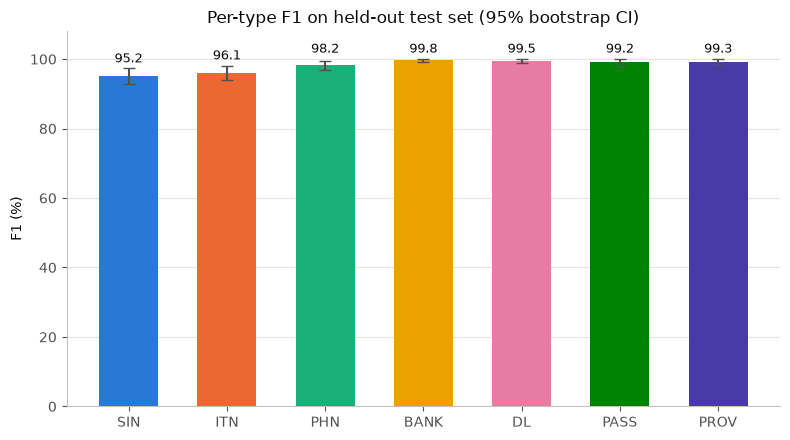

In [10]:
import numpy as np

order = [l for l in TYPE_ORDER if l in labels]
f1 = [base[l][2] * 100 for l in order]
lo_ = [np.percentile(boot[l], 2.5) * 100 for l in order]
hi_ = [np.percentile(boot[l], 97.5) * 100 for l in order]
err = [[max(f - l, 0) for f, l in zip(f1, lo_)], [max(h - f, 0) for h, f in zip(hi_, f1)]]
colors = [TYPE_COLOR[l] for l in order]
xlabels = [SHORT[l] for l in order]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(xlabels, f1, color=colors, width=0.6, zorder=3)
ax.errorbar(xlabels, f1, yerr=err, fmt="none", ecolor="#52514e", elinewidth=1.5, capsize=4, zorder=4)
for bar, val in zip(bars, f1):
    ax.text(bar.get_x() + bar.get_width() / 2, min(val + 3, 101), f"{val:.1f}",
            ha="center", va="bottom", fontsize=9, color="#0b0b0b")
ax.set_ylim(0, 108)
ax.set_ylabel("F1 (%)")
ax.set_title("Per-type F1 on held-out test set (95% bootstrap CI)")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.grid(axis="y", color="#e5e4e0", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig("per_type_f1.png", dpi=140)
plt.show()


### Entity confusion matrix

Rows are gold labels, columns are predicted labels (plus a MISS column for
gold entities the model didn't predict at all); off-diagonal cells are
label-confusions, not just misses.

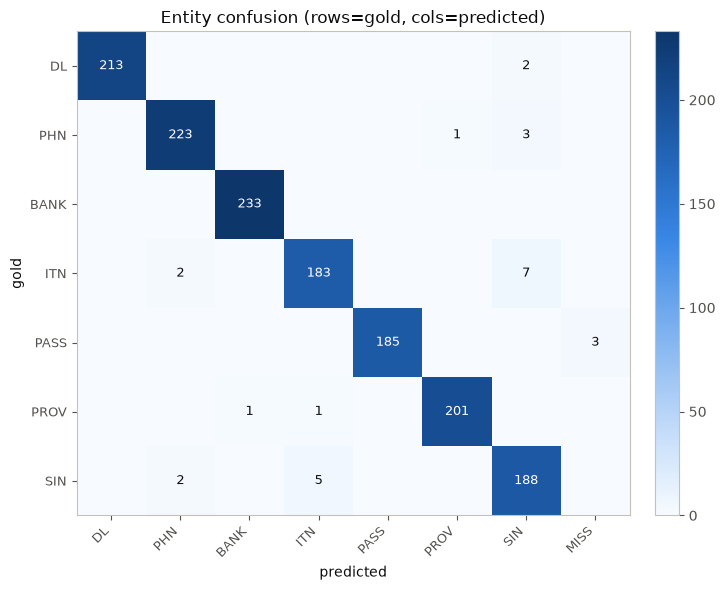

Spurious (predicted, no gold overlap): {}


In [11]:
fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(M, cmap=BLUE_CMAP)
ax.set_xticks(range(K + 1)); ax.set_xticklabels(axis, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(K)); ax.set_yticklabels([SHORT.get(l, l) for l in labels], fontsize=9)
ax.set_xlabel("predicted"); ax.set_ylabel("gold")
ax.set_title("Entity confusion (rows=gold, cols=predicted)")
for i in range(K):
    for j in range(K + 1):
        if M[i, j]:
            ax.text(j, i, M[i, j], ha="center", va="center",
                    color="white" if M[i, j] > M.max() / 2 else "#0b0b0b", fontsize=9)
fig.colorbar(im, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig("confusion_matrix.png", dpi=140)
plt.show()
print("Spurious (predicted, no gold overlap):",
      {SHORT.get(labels[i], labels[i]): int(spur[i]) for i in range(K) if spur[i]})


## 2. OntoNotes base-type diagnostic

The main smoke test only scores the 7 Canadian labels, so errors on inherited
OntoNotes types (e.g. "Android 14" → MONEY, boundary slips on PERSON/ORG) pass
silently. This adds gold annotations for the 18 inherited OntoNotes types over
the same smoke-test sentences and scores those too. It's a small, partly
subjective diagnostic — 10 of the 18 types have no gold positive here, so their
recall reads "-" (precision-only). Copied from `evaluation/eval_ontonotes.py`.

In [12]:
ONTO_TYPES = ["CARDINAL", "DATE", "EVENT", "FAC", "GPE", "LANGUAGE", "LAW", "LOC", "MONEY",
              "NORP", "ORDINAL", "ORG", "PERCENT", "PERSON", "PRODUCT", "QUANTITY", "TIME", "WORK_OF_ART"]

SIN_H, SIN_S, SIN_P = "130-692-544", "130 692 544", "130692544"
PHN_H, PHN_S, PHN_P = "257-574-243", "257 574 243", "257574243"
ITN_H, ITN_S, ITN_P = "459-311-601", "459 311 601", "459311601"
PROV_A, PROV_B = "748159263", "390215476"
BANK_A, BANK_B, BANK_C = "18016-003-86796296", "12345 006 7891234", "23456-001-98765432"
DL_AB, DL_BC, DL_ON, DL_SK = "428913576", "1234567", "A12345678901234", "12345678"
PASS_A, PASS_B, PASS_C, PASS_D = "AB123456", "CD234567", "A123456BC", "X987654YZ"

SIN = "CANADIAN_SOCIAL_INSURANCE_NUMBER"; ITN = "CANADIAN_INDIVIDUAL_TAX_NUMBER"
PHN = "ALBERTA_PERSONAL_HEALTH_NUMBER"; BANK = "CANADIAN_BANK_ACCOUNT_NUMBER"
DL = "ALBERTA_DRIVERS_LICENCE_NUMBER"; PASS = "CANADIAN_PASSPORT_NUMBER"
PROV = "CANADIAN_PROVIDER_IDENTIFIER"

ONTO_CASES = [
    (f"Please update SIN {SIN_S} in the payroll system.", {SIN}, []),
    (f"Employee SIN: {SIN_H} has been verified by HR.", {SIN}, []),
    (f"Her social insurance number is {SIN_P}.", {SIN}, []),
    (f"Add {SIN_S} to the T4 batch for next week.", {SIN}, [("next week", "DATE")]),
    (f"Service Canada confirmed SIN {SIN_H} belongs to the applicant.", {SIN}, [("Service Canada", "ORG")]),
    (f"Please update PHN {PHN_H} in the clinic system.", {PHN}, []),
    (f"Patient AHCIP number {PHN_S} is on file.", {PHN}, []),
    (f"Verify Alberta health number {PHN_P} for the new registration.", {PHN}, []),
    (f"PHN: {PHN_H} billing approved.", {PHN}, []),
    (f"The personal health number on the form reads {PHN_S}.", {PHN}, []),
    (f"The CRA ITN is {ITN_H} for the non-resident filer.", {ITN}, [("CRA", "ORG")]),
    (f"Individual tax number {ITN_S} was registered last quarter.", {ITN}, [("last quarter", "DATE")]),
    (f"Please enter ITN: {ITN_H} in the tax software.", {ITN}, []),
    (f"Non-resident ITN {ITN_P} needs annual review.", {ITN}, []),
    (f"Tax number {ITN_H} is linked to this account.", {ITN}, []),
    (f"Wire transfer to {BANK_A}.", {BANK}, []),
    (f"Bank details: {BANK_B}.", {BANK}, []),
    (f"Direct deposit to {BANK_A} has been set up.", {BANK}, []),
    (f"Account {BANK_C} is the new payroll destination.", {BANK}, []),
    (f"Please verify {BANK_B} for the refund.", {BANK}, []),
    (f"Alberta DL {DL_AB} is on file for the new employee.", {DL}, []),
    (f"Driver's licence number {DL_BC} has expired.", {DL}, []),
    (f"Please update DL# {DL_SK} in the registry.", {DL}, []),
    (f"Operator licence {DL_ON} was renewed last week.", {DL}, [("last week", "DATE")]),
    (f"AB licence {DL_AB} verified at the dealership.", {DL}, []),
    (f"Canadian passport {PASS_A} expires next year.", {PASS}, [("next year", "DATE")]),
    (f"Passport number {PASS_C} was confirmed by CBSA.", {PASS}, [("CBSA", "ORG")]),
    (f"Travel document {PASS_D} needs verification before boarding.", {PASS}, []),
    (f"Please scan passport {PASS_B} at check-in.", {PASS}, []),
    (f"The passport on file is {PASS_A}.", {PASS}, []),
    (f"Billing provider {PROV_A} submitted the claim.", {PROV}, []),
    (f"Practitioner ID {PROV_B} needs renewal.", {PROV}, []),
    (f"AHS provider {PROV_A} was added to the roster.", {PROV}, []),
    (f"Please verify provider no. {PROV_B} for this referral.", {PROV}, []),
    (f"CPSA {PROV_A} is registered for the new clinic.", {PROV}, []),
    (f"Patient SIN {SIN_H} and PHN {PHN_H} both updated.", {SIN, PHN}, []),
    (f"Process refund to {BANK_C} for SIN {SIN_S}.", {BANK, SIN}, []),
    (f"ITN {ITN_H} and passport {PASS_A} are on file.", {ITN, PASS}, []),
    (f"Provider {PROV_A} billed PHN {PHN_H} last Tuesday.", {PROV, PHN}, [("last Tuesday", "DATE")]),
    (f"DL {DL_AB} and passport {PASS_C} verified at the border.", {DL, PASS}, []),
    ("Sarah Patel from CRA called on March 15, 2026.", set(),
        [("Sarah Patel", "PERSON"), ("CRA", "ORG"), ("March 15, 2026", "DATE")]),
    ("Dr. Jonathan Smith updated the records yesterday.", set(),
        [("Dr. Jonathan Smith", "PERSON"), ("yesterday", "DATE")]),
    ("The meeting at Foothills Medical Centre starts at 9:00 a.m.", set(),
        [("Foothills Medical Centre", "FAC"), ("9:00 a.m.", "TIME")]),
    ("Alberta Health Services processed 2,500 applications in Q1 2026.", set(),
        [("Alberta Health Services", "ORG"), ("2,500", "CARDINAL"), ("Q1 2026", "DATE")]),
    ("Please contact the Canada Revenue Agency in Edmonton by Friday.", set(),
        [("Canada Revenue Agency", "ORG"), ("Edmonton", "GPE"), ("Friday", "DATE")]),
    ("Please update the system and restart the application.", set(), []),
    ("The meeting has been postponed to next week.", set(), [("next week", "DATE")]),
    ("Submit your feedback through the online form.", set(), []),
    ("All systems are operating normally today.", set(), [("today", "DATE")]),
    ("Thank you for reaching out to our team.", set(), []),
    (f"Reference {ITN_H} appears in the meeting notes.", set(), []),
    (f"Invoice {PHN_H} was paid on Tuesday.", set(), [("Tuesday", "DATE")]),
    ("Page 257 of 574 contains the executive summary.", set(), []),
    ("Phone extension 4591 reached voicemail.", set(), []),
    (f"Order number {SIN_H} has shipped from the warehouse.", set(), []),
    (f"Lot {BANK_A} shipped from the warehouse.", set(), []),
    (f"Asset tag {PROV_A} was scanned during inventory.", set(), []),
    (f"Conference room {PASS_C} is booked for the morning.", set(), []),
    (f"PHN {PHN_H} is different from ITN {ITN_H} on the form.", {PHN, ITN}, []),
    (f"Update SIN {SIN_S} but do not confuse it with PHN {PHN_S}.", {SIN, PHN}, []),
    (f"The CRA ITN {ITN_H} is for tax purposes only, not health billing.", {ITN}, [("CRA", "ORG")]),
    (f"Note: {SIN_H} is the SIN; {PHN_H} is the PHN.", {SIN, PHN}, []),
    (f"Hey, can you double-check the SIN {SIN_S} for me?", {SIN}, []),
    (f"FYI the PHN on the patient's file is {PHN_H}.", {PHN}, []),
    (f"Quick note \u2014 Sarah's ITN is {ITN_H}, please update.", {ITN}, [("Sarah", "PERSON")]),
    (f"Heads up: the bank account {BANK_A} was flagged for review.", {BANK}, []),
    (f"Need to verify Alberta DL {DL_AB} before the test drive.", {DL}, []),
    (SIN_H, set(), []),
    (f"{PHN_S}.", set(), []),
    (f"{ITN_H} \u2014 ITN on file.", {ITN}, []),
    (f"Passport: {PASS_A}", {PASS}, []),
    (f"SIN {SIN_H}", {SIN}, []),
    (f"Maya Singh's SIN {SIN_S} was verified by HR on March 12, 2026.", {SIN},
        [("Maya Singh", "PERSON"), ("March 12, 2026", "DATE")]),
    (f"Send the refund of $1,500.00 to {BANK_A} by Friday.", {BANK},
        [("$1,500.00", "MONEY"), ("Friday", "DATE")]),
    (f"Dr. Andr\u00e9 L\u00e9vesque updated PHN {PHN_H} at Misericordia Community Hospital.", {PHN},
        [("Dr. Andr\u00e9 L\u00e9vesque", "PERSON"), ("Misericordia Community Hospital", "FAC")]),
    (f"The Canada Revenue Agency processed ITN {ITN_H} last quarter.", {ITN},
        [("Canada Revenue Agency", "ORG"), ("last quarter", "DATE")]),
    ("Officer Yang at Calgary International Airport verified passport AB123456.", {PASS},
        [("Officer Yang", "PERSON"), ("Calgary International Airport", "FAC")]),
]

onto = {t: {"tp": 0, "fp": 0, "fn": 0} for t in ONTO_TYPES}
onto_failures = []

for idx, (text, can_exp, onto_gold) in enumerate(ONTO_CASES, 1):
    doc = nlp(text)
    pred_onto = {(e.text, e.label_) for e in doc.ents if e.label_ in ONTO_TYPES}
    gold_onto = set(onto_gold)
    for span in gold_onto & pred_onto: onto[span[1]]["tp"] += 1
    missing = gold_onto - pred_onto
    spurious = pred_onto - gold_onto
    for _, lab in missing: onto[lab]["fn"] += 1
    for _, lab in spurious: onto[lab]["fp"] += 1
    if missing or spurious:
        onto_failures.append((idx, text, sorted(missing), sorted(spurious)))

def onto_prf(d):
    tp, fp, fn = d["tp"], d["fp"], d["fn"]
    P = tp / (tp + fp) if tp + fp else None
    R = tp / (tp + fn) if tp + fn else None
    F = 2 * P * R / (P + R) if P and R else (0.0 if (tp + fp + fn) else None)
    return P, R, F

def cell(x): return " -  " if x is None else f"{x*100:4.0f}"

print("=" * 78)
print("ONTONOTES (18 base types) \u2014 span-level over the OntoNotes diagnostic cases")
print("=" * 78)
print(f"{'type':12s} {'P':>5s} {'R':>5s} {'F':>5s}   {'TP':>3s} {'FP':>3s} {'FN':>3s}   support")
print("-" * 78)
onto_fails = []
for t in ONTO_TYPES:
    P, R, F = onto_prf(onto[t])
    sup = onto[t]["tp"] + onto[t]["fn"]
    flag = ""
    if onto[t]["fp"] or onto[t]["fn"]:
        flag = "  <-- FAILS"; onto_fails.append(t)
    print(f"{t:12s} {cell(P):>5s} {cell(R):>5s} {cell(F):>5s}   "
          f"{onto[t]['tp']:>3d} {onto[t]['fp']:>3d} {onto[t]['fn']:>3d}   "
          f"{sup if sup else '-':>4}{flag}")

print("\nBase types with ANY error (FP or FN):")
print("  " + (", ".join(onto_fails) if onto_fails else "none"))

print("\n" + "=" * 78)
print("OntoNotes failures (per sentence)")
print("=" * 78)
for idx, text, missing, spurious in onto_failures:
    print(f"\n[{idx}] {text}")
    if missing: print("   MISSED   :", ", ".join(f'"{t}"->{l}' for t, l in missing))
    if spurious: print("   SPURIOUS :", ", ".join(f'"{t}"->{l}' for t, l in spurious))


ONTONOTES (18 base types) — span-level over the OntoNotes diagnostic cases
type             P     R     F    TP  FP  FN   support
------------------------------------------------------------------------------
CARDINAL       100   100   100     1   0   0      1
DATE           100    80    89    12   0   3     15  <-- FAILS
EVENT          -     -     -       0   0   0      -
FAC            100   100   100     3   0   0      3
GPE            100   100   100     1   0   0      1
LANGUAGE       -     -     -       0   0   0      -
LAW            -     -     -       0   0   0      -
LOC            -     -     -       0   0   0      -
MONEY          100   100   100     1   0   0      1
NORP             0   -       0     0   2   0      -  <-- FAILS
ORDINAL        -     -     -       0   0   0      -
ORG             80    50    62     4   1   4      8  <-- FAILS
PERCENT        -     -     -       0   0   0      -
PERSON         100    83    91     5   0   1      6  <-- FAILS
PRODUCT          0 

### OntoNotes per-type P/R/F1 (types with gold support in these cases)

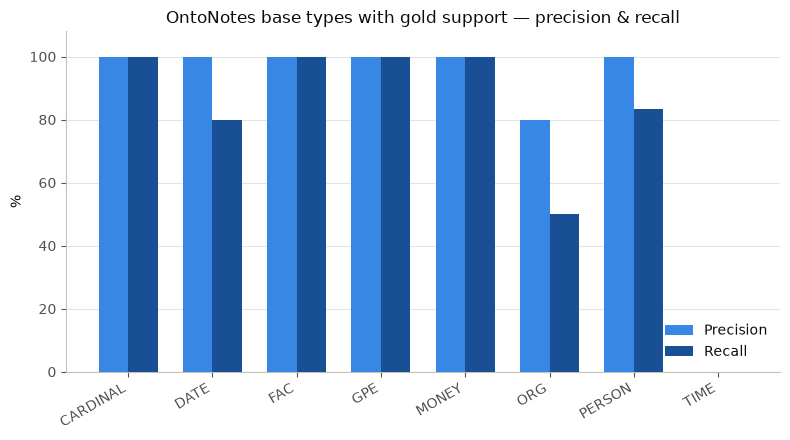

Types with no gold instance in these cases (precision-only, not plotted): ['EVENT', 'LANGUAGE', 'LAW', 'LOC', 'NORP', 'ORDINAL', 'PERCENT', 'PRODUCT', 'QUANTITY', 'WORK_OF_ART']


In [25]:
onto_supported = [t for t in ONTO_TYPES if onto[t]["tp"] + onto[t]["fn"] > 0]
p_ = [(onto_prf(onto[t])[0] or 0.0) * 100 for t in onto_supported]
r_ = [(onto_prf(onto[t])[1] or 0.0) * 100 for t in onto_supported]

x = np.arange(len(onto_supported))
w = 0.35
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - w / 2, p_, width=w, label="Precision", color=SEQ_BLUE[3], zorder=3)
ax.bar(x + w / 2, r_, width=w, label="Recall", color=SEQ_BLUE[5], zorder=3)
ax.set_xticks(x); ax.set_xticklabels(onto_supported, rotation=30, ha="right")
ax.set_ylim(0, 108)
ax.set_ylabel("%")
ax.set_title("OntoNotes base types with gold support — precision & recall")
ax.legend(frameon=False, loc="lower right")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.grid(axis="y", color="#e5e4e0", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig("ontonotes_per_type.png", dpi=140)
plt.show()
print("Types with no gold instance in these cases (precision-only, not plotted):",
      [t for t in ONTO_TYPES if t not in onto_supported])


## 3. Baseline comparison — Presidio (rule-based) vs the fine-tuned model

Scores stock Presidio, Presidio + hand-written Canadian `PatternRecognizer`s, and
the fine-tuned model on the same 54 cases. Copied from
`evaluation/compare_presidio.py` (which imports the shared case list from
`evaluation/smoke_cases.py` — pasted first below).

In [14]:
SIN  = "CANADIAN_SOCIAL_INSURANCE_NUMBER"
ITN  = "CANADIAN_INDIVIDUAL_TAX_NUMBER"
PHN  = "ALBERTA_PERSONAL_HEALTH_NUMBER"
BANK = "CANADIAN_BANK_ACCOUNT_NUMBER"
DL   = "ALBERTA_DRIVERS_LICENCE_NUMBER"
PASS = "CANADIAN_PASSPORT_NUMBER"
PROV = "CANADIAN_PROVIDER_IDENTIFIER"

SIN_H, SIN_S, SIN_P = "130-692-544", "130 692 544", "130692544"
PHN_H, PHN_S, PHN_P = "257-574-243", "257 574 243", "257574243"
ITN_H, ITN_S, ITN_P = "459-311-601", "459 311 601", "459311601"
PROV_A, PROV_B      = "748159263", "390215476"
BANK_A = "18016-003-86796296"
BANK_B = "12345 006 7891234"
BANK_C = "23456-001-98765432"
DL_AB  = "428913576"
DL_BC  = "1234567"
DL_ON  = "A12345678901234"
DL_SK  = "12345678"
PASS_A = "AB123456"
PASS_B = "CD234567"
PASS_C = "A123456BC"
PASS_D = "X987654YZ"

CASES = [
    # SIN
    (f"Please update SIN {SIN_S} in the payroll system.",            {SIN}),
    (f"Employee SIN: {SIN_H} has been verified by HR.",              {SIN}),
    (f"Her social insurance number is {SIN_P}.",                     {SIN}),
    (f"Service Canada confirmed SIN {SIN_H} belongs to the applicant.", {SIN}),
    # PHN
    (f"Please update PHN {PHN_H} in the clinic system.",             {PHN}),
    (f"Patient AHCIP number {PHN_S} is on file.",                    {PHN}),
    (f"Verify Alberta health number {PHN_P} for the new registration.", {PHN}),
    (f"PHN: {PHN_H} billing approved.",                              {PHN}),
    (f"The personal health number on the form reads {PHN_S}.",       {PHN}),
    # ITN
    (f"The CRA ITN is {ITN_H} for the non-resident filer.",          {ITN}),
    (f"Individual tax number {ITN_S} was registered last quarter.",  {ITN}),
    (f"Please enter ITN: {ITN_H} in the tax software.",              {ITN}),
    (f"Non-resident ITN {ITN_P} needs annual review.",               {ITN}),
    (f"Tax number {ITN_H} is linked to this account.",               {ITN}),
    # Bank
    (f"Wire transfer to {BANK_A}.",                                  {BANK}),
    (f"Bank details: {BANK_B}.",                                     {BANK}),
    (f"Direct deposit to {BANK_A} has been set up.",                 {BANK}),
    (f"Account {BANK_C} is the new payroll destination.",            {BANK}),
    # DL
    (f"Alberta DL {DL_AB} is on file for the new employee.",         {DL}),
    (f"Driver's licence number {DL_BC} has expired.",                {DL}),
    (f"Please update DL# {DL_SK} in the registry.",                  {DL}),
    (f"AB licence {DL_AB} verified at the dealership.",              {DL}),
    # Passport
    (f"Canadian passport {PASS_A} expires next year.",               {PASS}),
    (f"Passport number {PASS_C} was confirmed by CBSA.",             {PASS}),
    (f"Please scan passport {PASS_B} at check-in.",                  {PASS}),
    (f"The passport on file is {PASS_A}.",                           {PASS}),
    # Provider
    (f"Billing provider {PROV_A} submitted the claim.",              {PROV}),
    (f"Practitioner ID {PROV_B} needs renewal.",                     {PROV}),
    (f"AHS provider {PROV_A} was added to the roster.",              {PROV}),
    (f"Please verify provider no. {PROV_B} for this referral.",      {PROV}),
    # Multiple
    (f"Patient SIN {SIN_H} and PHN {PHN_H} both updated.",           {SIN, PHN}),
    (f"Process refund to {BANK_C} for SIN {SIN_S}.",                 {BANK, SIN}),
    (f"ITN {ITN_H} and passport {PASS_A} are on file.",              {ITN, PASS}),
    (f"DL {DL_AB} and passport {PASS_C} verified at the border.",    {DL, PASS}),
    # Negatives
    ("Please update the system and restart the application.",        set()),
    ("The meeting has been postponed to next week.",                 set()),
    ("All systems are operating normally today.",                    set()),
    # Hard negatives (look like IDs, no keyword)
    (f"Reference {ITN_H} appears in the meeting notes.",             set()),
    (f"Invoice {PHN_H} was paid on Tuesday.",                        set()),
    ("Page 257 of 574 contains the executive summary.",              set()),
    (f"Order number {SIN_H} has shipped from the warehouse.",        set()),
    (f"Lot {BANK_A} shipped from the warehouse.",                    set()),
    (f"Asset tag {PROV_A} was scanned during inventory.",            set()),
    (f"Conference room {PASS_C} is booked for the morning.",         set()),
    # Disambiguation
    (f"PHN {PHN_H} is different from ITN {ITN_H} on the form.",      {PHN, ITN}),
    (f"Update SIN {SIN_S} but do not confuse it with PHN {PHN_S}.",  {SIN, PHN}),
    # Informal
    (f"Hey, can you double-check the SIN {SIN_S} for me?",           {SIN}),
    (f"FYI the PHN on the patient's file is {PHN_H}.",               {PHN}),
    # Edge / bare (should be negative)
    (SIN_H,                                                          set()),
    (f"{PHN_S}.",                                                    set()),
    (f"Passport: {PASS_A}",                                          {PASS}),
    (f"SIN {SIN_H}",                                                 {SIN}),
    # Domain numeric decoys (version/error/duration) -> negative
    ("After updating to version 2.4.1 the app finally stopped crashing.", set()),
    ("Got error code 0x80004 three times before the health card loaded.", set()),
    ("Support ticket 88231 has been open for two weeks with no reply.", set()),
]
print(f"{len(CASES)} shared cases loaded")


55 shared cases loaded


In [15]:
from presidio_analyzer import AnalyzerEngine, PatternRecognizer, Pattern

PRESIDIO_TO_CANADIAN = {
    "CA_SIN": SIN, "CA_ITN": ITN, "CA_PHN": PHN, "CA_BANK": BANK,
    "CA_DL": DL, "CA_PASSPORT": PASS, "CA_PROVIDER": PROV,
    "US_SSN": SIN, "US_ITIN": ITN, "UK_NHS": PHN,
    "US_BANK_NUMBER": BANK, "IBAN_CODE": BANK,
    "US_DRIVER_LICENSE": DL, "US_PASSPORT": PASS, "MEDICAL_LICENSE": PROV,
}

NINE_RE = r"(?:\b\d{3}[- ]\d{3}[- ]\d{3}\b|\b\d{9}\b)"
BANK_RE = r"(?:\b\d{5}[- ]\d{3}[- ]\d{7,12}\b|\b(?:account|acct\.?)\s+\d{7,12}\b)"
PASS_RE = r"(?:\b[A-Z]\d{6}[A-Z]{2}\b|\b[A-Z]{2}\d{6}\b)"
DL_RE   = r"(?:\b[A-Z]?\d{6,9}\b|\b[A-Z]\d{9,14}\b|\b[A-Z0-9]{12,14}\b)"

def rec(entity, regex, context, score=0.4):
    return PatternRecognizer(
        supported_entity=entity,
        patterns=[Pattern(name=entity.lower(), regex=regex, score=score)],
        context=context,
    )

CUSTOM_RECOGNIZERS = [
    rec("CA_SIN",      NINE_RE, ["sin", "social", "insurance"]),
    rec("CA_ITN",      NINE_RE, ["itn", "individual", "tax"]),
    rec("CA_PHN",      NINE_RE, ["phn", "ahcip", "health", "personal"]),
    rec("CA_PROVIDER", NINE_RE, ["provider", "practitioner", "cpsa", "ahs", "billing"]),
    rec("CA_BANK",     BANK_RE, ["account", "transit", "deposit", "bank", "wire"]),
    rec("CA_DL",       DL_RE,   ["licence", "license", "dl", "driver", "operator"]),
    rec("CA_PASSPORT", PASS_RE, ["passport", "travel", "document"]),
]
SCORE_THRESHOLD = 0.5

def canadian_labels_from(results):
    out = set()
    for r in results:
        lab = PRESIDIO_TO_CANADIAN.get(r.entity_type)
        if lab:
            out.add(lab)
    return out

print("Loading Presidio (spaCy en_core_web_lg under the hood)...")
analyzer = AnalyzerEngine()

def presidio_pass(texts):
    return [canadian_labels_from(
        analyzer.analyze(text=t, language="en", score_threshold=SCORE_THRESHOLD)
    ) for t, _ in texts]

stock_preds = presidio_pass(CASES)
for r in CUSTOM_RECOGNIZERS:
    analyzer.registry.add_recognizer(r)
custom_preds = presidio_pass(CASES)

model_preds = [{e.label_ for e in nlp(t).ents if e.label_ in CANADIAN} for t, _ in CASES]

def overall_pass(preds):
    scored = [(p, exp) for p, (_, exp) in zip(preds, CASES) if exp is not None]
    return sum(p == exp for p, exp in scored), len(scored)

def fp_on_clean(preds):
    return sum(1 for p, (_, exp) in zip(preds, CASES) if exp == set() and p)

cols = [("MODEL", model_preds), ("PRESIDIO-stock", stock_preds), ("PRESIDIO-custom", custom_preds)]

print("\n" + "=" * 72)
print("SUMMARY")
print("=" * 72)
hdr = f"{'engine':18s} {'exact-match':>12s} {'clean-text FPs':>15s}"
print(hdr); print("-" * len(hdr))
for name, preds in cols:
    ok, n = overall_pass(preds)
    print(f"{name:18s} {ok:>4d}/{n:<4d} {100*ok/n:>5.1f}% {fp_on_clean(preds):>10d}")


Loading Presidio (spaCy en_core_web_lg under the hood)...

SUMMARY
engine              exact-match  clean-text FPs
-----------------------------------------------
MODEL                50/55    90.9%          1
PRESIDIO-stock       15/55    27.3%          0
PRESIDIO-custom      54/55    98.2%          0


### ROC and Precision–Recall curves

spaCy's `EntityRecognizer` doesn't expose a per-span confidence score to
threshold-sweep, so the curves below are traced from Presidio's continuous
`score` (custom Canadian recognizers, threshold swept 0→1 over the same 54
cases). The fine-tuned model is overlaid as a single red dot — its one
hard-decision operating point — for comparison, not as a curve.

In [16]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import numpy as np

raw_scores = []
for text, _ in CASES:
    results = analyzer.analyze(text=text, language="en", score_threshold=0.0)
    best = {t: 0.0 for t in TYPE_ORDER}
    for r in results:
        lab = PRESIDIO_TO_CANADIAN.get(r.entity_type)
        if lab in best:
            best[lab] = max(best[lab], r.score)
    raw_scores.append(best)

y_true = {t: [] for t in TYPE_ORDER}
y_score = {t: [] for t in TYPE_ORDER}
for (text, exp), best in zip(CASES, raw_scores):
    if exp is None:
        continue
    for t in TYPE_ORDER:
        y_true[t].append(1 if t in exp else 0)
        y_score[t].append(best[t])

y_true_micro = np.concatenate([y_true[t] for t in TYPE_ORDER])
y_score_micro = np.concatenate([y_score[t] for t in TYPE_ORDER])

roc = {}
for t in TYPE_ORDER:
    if len(set(y_true[t])) < 2:
        continue
    fpr, tpr, _ = roc_curve(y_true[t], y_score[t])
    roc[t] = (fpr, tpr, auc(fpr, tpr))
fpr_micro, tpr_micro, _ = roc_curve(y_true_micro, y_score_micro)
roc_auc_micro = auc(fpr_micro, tpr_micro)

pr = {}
for t in TYPE_ORDER:
    if sum(y_true[t]) == 0:
        continue
    prec, rec_, _ = precision_recall_curve(y_true[t], y_score[t])
    pr[t] = (prec, rec_)
prec_micro, rec_micro, _ = precision_recall_curve(y_true_micro, y_score_micro)

# fine-tuned model's single hard-decision operating point on the same 54 cases
m_tp = m_fp = m_fn = m_tn = 0
for (text, exp), pred in zip(CASES, model_preds):
    if exp is None:
        continue
    for t in TYPE_ORDER:
        g, p_ = (t in exp), (t in pred)
        m_tp += g and p_; m_fp += p_ and not g; m_fn += g and not p_; m_tn += (not g) and (not p_)
model_tpr = m_tp / (m_tp + m_fn) if (m_tp + m_fn) else 0.0
model_fpr = m_fp / (m_fp + m_tn) if (m_fp + m_tn) else 0.0
model_p = m_tp / (m_tp + m_fp) if (m_tp + m_fp) else 0.0
model_r = m_tp / (m_tp + m_fn) if (m_tp + m_fn) else 0.0
print(f"Fine-tuned model operating point: TPR(recall)={model_tpr*100:.1f}%  FPR={model_fpr*100:.2f}%  precision={model_p*100:.1f}%")


Fine-tuned model operating point: TPR(recall)=91.3%  FPR=0.59%  precision=95.5%


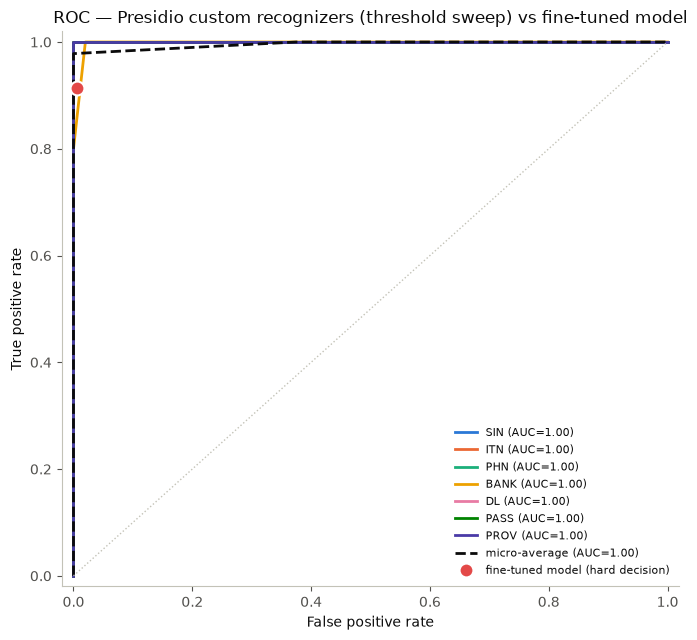

In [17]:
fig, ax = plt.subplots(figsize=(7, 6.5))
for t in TYPE_ORDER:
    if t not in roc:
        continue
    fpr, tpr, a = roc[t]
    ax.plot(fpr, tpr, color=TYPE_COLOR[t], linewidth=2, label=f"{SHORT[t]} (AUC={a:.2f})")
ax.plot(fpr_micro, tpr_micro, color="#0b0b0b", linewidth=2, linestyle="--",
        label=f"micro-average (AUC={roc_auc_micro:.2f})")
ax.plot([model_fpr], [model_tpr], marker="o", markersize=10, color="#e34948",
        markeredgecolor="white", markeredgewidth=1.5, linestyle="none", zorder=5,
        label="fine-tuned model (hard decision)")
ax.plot([0, 1], [0, 1], color="#c3c2b7", linewidth=1, linestyle=":")
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("ROC \u2014 Presidio custom recognizers (threshold sweep) vs fine-tuned model")
ax.legend(frameon=False, fontsize=8, loc="lower right")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
fig.tight_layout()
fig.savefig("roc_curve.png", dpi=140)
plt.show()


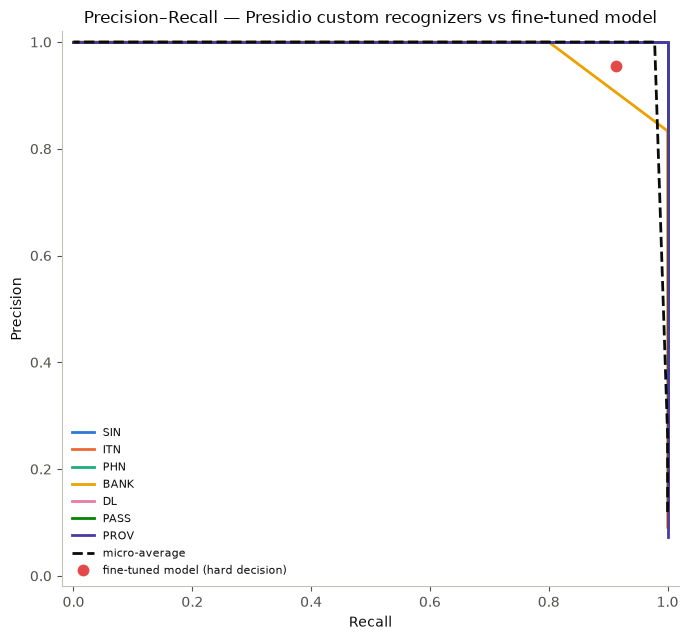

In [18]:
fig, ax = plt.subplots(figsize=(7, 6.5))
for t in TYPE_ORDER:
    if t not in pr:
        continue
    prec, rec_ = pr[t]
    ax.plot(rec_, prec, color=TYPE_COLOR[t], linewidth=2, label=SHORT[t])
ax.plot(rec_micro, prec_micro, color="#0b0b0b", linewidth=2, linestyle="--", label="micro-average")
ax.plot([model_r], [model_p], marker="o", markersize=10, color="#e34948",
        markeredgecolor="white", markeredgewidth=1.5, linestyle="none", zorder=5,
        label="fine-tuned model (hard decision)")
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision\u2013Recall \u2014 Presidio custom recognizers vs fine-tuned model")
ax.legend(frameon=False, fontsize=8, loc="lower left")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
fig.tight_layout()
fig.savefig("pr_curve.png", dpi=140)
plt.show()


## 4. Smoke tests

**4a. Primary smoke test** — 80 hand-written out-of-distribution cases scored
on the 7 Canadian labels (value-only labelling: the trigger word is context,
only the identifier value should be tagged). Copied from
`evaluation/smoke_test.py`.

In [20]:
SIN  = "CANADIAN_SOCIAL_INSURANCE_NUMBER"
ITN  = "CANADIAN_INDIVIDUAL_TAX_NUMBER"
PHN  = "ALBERTA_PERSONAL_HEALTH_NUMBER"
BANK = "CANADIAN_BANK_ACCOUNT_NUMBER"
DL   = "ALBERTA_DRIVERS_LICENCE_NUMBER"
PASS = "CANADIAN_PASSPORT_NUMBER"
PROV = "CANADIAN_PROVIDER_IDENTIFIER"

SIN_H, SIN_S, SIN_P = "130-692-544", "130 692 544", "130692544"
PHN_H, PHN_S, PHN_P = "257-574-243", "257 574 243", "257574243"
ITN_H, ITN_S, ITN_P = "459-311-601", "459 311 601", "459311601"
PROV_A, PROV_B      = "748159263", "390215476"
BANK_A = "18016-003-86796296"
BANK_B = "12345 006 7891234"
BANK_C = "23456-001-98765432"
DL_AB  = "428913576"
DL_BC  = "1234567"
DL_ON  = "A12345678901234"
DL_SK  = "12345678"
PASS_A = "AB123456"
PASS_B = "CD234567"
PASS_C = "A123456BC"
PASS_D = "X987654YZ"

main_smoke_tests = [
    # SIN
    (f"Please update SIN {SIN_S} in the payroll system.",            {SIN}),
    (f"Employee SIN: {SIN_H} has been verified by HR.",              {SIN}),
    (f"Her social insurance number is {SIN_P}.",                     {SIN}),
    (f"Add {SIN_S} to the T4 batch for next week.",                  {SIN}),
    (f"Service Canada confirmed SIN {SIN_H} belongs to the applicant.", {SIN}),
    # PHN
    (f"Please update PHN {PHN_H} in the clinic system.",             {PHN}),
    (f"Patient AHCIP number {PHN_S} is on file.",                    {PHN}),
    (f"Verify Alberta health number {PHN_P} for the new registration.", {PHN}),
    (f"PHN: {PHN_H} \u2014 billing approved.",                       {PHN}),
    (f"The personal health number on the form reads {PHN_S}.",       {PHN}),
    # ITN
    (f"The CRA ITN is {ITN_H} for the non-resident filer.",          {ITN}),
    (f"Individual tax number {ITN_S} was registered last quarter.",  {ITN}),
    (f"Please enter ITN: {ITN_H} in the tax software.",              {ITN}),
    (f"Non-resident ITN {ITN_P} needs annual review.",               {ITN}),
    (f"Tax number {ITN_H} is linked to this account.",               {ITN}),
    # Bank
    (f"Wire transfer to {BANK_A}.",                                  {BANK}),
    (f"Bank details: {BANK_B}.",                                     {BANK}),
    (f"Direct deposit to {BANK_A} has been set up.",                 {BANK}),
    (f"Account {BANK_C} is the new payroll destination.",            {BANK}),
    (f"Please verify {BANK_B} for the refund.",                      {BANK}),
    # DL
    (f"Alberta DL {DL_AB} is on file for the new employee.",         {DL}),
    (f"Driver's licence number {DL_BC} has expired.",                {DL}),
    (f"Please update DL# {DL_SK} in the registry.",                  {DL}),
    (f"Operator licence {DL_ON} was renewed last week.",             {DL}),
    (f"AB licence {DL_AB} verified at the dealership.",              {DL}),
    # Passport
    (f"Canadian passport {PASS_A} expires next year.",               {PASS}),
    (f"Passport number {PASS_C} was confirmed by CBSA.",             {PASS}),
    (f"Travel document {PASS_D} needs verification before boarding.", {PASS}),
    (f"Please scan passport {PASS_B} at check-in.",                  {PASS}),
    (f"The passport on file is {PASS_A}.",                           {PASS}),
    # Provider
    (f"Billing provider {PROV_A} submitted the claim.",              {PROV}),
    (f"Practitioner ID {PROV_B} needs renewal.",                     {PROV}),
    (f"AHS provider {PROV_A} was added to the roster.",              {PROV}),
    (f"Please verify provider no. {PROV_B} for this referral.",      {PROV}),
    (f"CPSA {PROV_A} is registered for the new clinic.",             {PROV}),
    # Multiple
    (f"Patient SIN {SIN_H} and PHN {PHN_H} both updated.",           {SIN, PHN}),
    (f"Process refund to {BANK_C} for SIN {SIN_S}.",                 {BANK, SIN}),
    (f"ITN {ITN_H} and passport {PASS_A} are on file.",              {ITN, PASS}),
    (f"Provider {PROV_A} billed PHN {PHN_H} last Tuesday.",          {PROV, PHN}),
    (f"DL {DL_AB} and passport {PASS_C} verified at the border.",    {DL, PASS}),
    # OntoNotes only (no Canadian PII expected)
    ("Sarah Patel from CRA called on March 15, 2026.",               set()),
    ("Dr. Jonathan Smith updated the records yesterday.",            set()),
    ("The meeting at Foothills Medical Centre starts at 9:00 a.m.",  set()),
    ("Alberta Health Services processed 2,500 applications in Q1 2026.", set()),
    ("Please contact the Canada Revenue Agency in Edmonton by Friday.", set()),
    # Negatives
    ("Please update the system and restart the application.",        set()),
    ("The meeting has been postponed to next week.",                 set()),
    ("Submit your feedback through the online form.",                set()),
    ("All systems are operating normally today.",                    set()),
    ("Thank you for reaching out to our team.",                      set()),
    # Hard negatives
    (f"Reference {ITN_H} appears in the meeting notes.",             set()),
    (f"Invoice {PHN_H} was paid on Tuesday.",                        set()),
    ("Page 257 of 574 contains the executive summary.",              set()),
    ("Phone extension 4591 reached voicemail.",                      set()),
    (f"Order number {SIN_H} has shipped from the warehouse.",        set()),
    (f"Lot {BANK_A} shipped from the warehouse.",                    set()),
    (f"Asset tag {PROV_A} was scanned during inventory.",            set()),
    (f"Conference room {PASS_C} is booked for the morning.",         set()),
    # Disambiguation
    (f"PHN {PHN_H} is different from ITN {ITN_H} on the form.",      {PHN, ITN}),
    (f"Update SIN {SIN_S} but do not confuse it with PHN {PHN_S}.",  {SIN, PHN}),
    (f"The CRA ITN {ITN_H} is for tax purposes only, not health billing.", {ITN}),
    (f"Note: {SIN_H} is the SIN; {PHN_H} is the PHN.",               {SIN, PHN}),
    # Informal
    (f"Hey, can you double-check the SIN {SIN_S} for me?",           {SIN}),
    (f"FYI the PHN on the patient's file is {PHN_H}.",               {PHN}),
    (f"Quick note \u2014 Sarah's ITN is {ITN_H}, please update.",    {ITN}),
    (f"Heads up: the bank account {BANK_A} was flagged for review.", {BANK}),
    (f"Need to verify Alberta DL {DL_AB} before the test drive.",    {DL}),
    # Edge cases
    (SIN_H,                                                          set()),
    (f"{PHN_S}.",                                                    set()),
    (f"{ITN_H} \u2014 ITN on file.",                                 {ITN}),
    (f"Passport: {PASS_A}",                                          {PASS}),
    (f"SIN {SIN_H}",                                                 {SIN}),
    # Mixed
    (f"Maya Singh's SIN {SIN_S} was verified by HR on March 12, 2026.", {SIN}),
    (f"Send the refund of $1,500.00 to {BANK_A} by Friday.",         {BANK}),
    (f"Dr. Andr\u00e9 L\u00e9vesque updated PHN {PHN_H} at Misericordia Community Hospital.", {PHN}),
    (f"The Canada Revenue Agency processed ITN {ITN_H} last quarter.", {ITN}),
    (f"Officer Yang at Calgary International Airport verified passport {PASS_A}.", {PASS}),
    # Informational only (not scored)
    ("Wire transfer to transit 18016 account 86796296.",            None),
    ("Direct deposit to acct 86796296 has been set up.",            None),
    ("Account number 4567891234 is the new payroll destination.",   None),
]

print(f"\n{'='*80}")
print(f"Running {len(main_smoke_tests)} smoke tests   (model: {MODEL_PATH})")
print('='*80)

main_scored = main_passed = 0
main_failures = []
for i, (text, expect) in enumerate(main_smoke_tests, 1):
    doc = nlp(text)
    found_can = {e.label_ for e in doc.ents if e.label_ in CANADIAN}
    if expect is None:
        status = "info"
    else:
        main_scored += 1
        ok = (found_can == expect)
        main_passed += ok
        status = "PASS" if ok else "FAIL"
        if not ok:
            main_failures.append((i, text, expect, found_can))
    if status == "FAIL":
        print(f"[FAIL] [{i}] '{text}'  expected {sorted(expect) or set()}  got {sorted(found_can) or set()}")

print(f"\n{'='*80}")
print((f"SCORED: {main_passed}/{main_scored} passed   ({(100*main_passed/main_scored):.1f}%)") if main_scored else "no scored tests")
print('='*80)



Running 80 smoke tests   (model: ../output_stage2/model-best)
[FAIL] [4] 'Add 130 692 544 to the T4 batch for next week.'  expected ['CANADIAN_SOCIAL_INSURANCE_NUMBER']  got set()
[FAIL] [15] 'Tax number 459-311-601 is linked to this account.'  expected ['CANADIAN_INDIVIDUAL_TAX_NUMBER']  got set()
[FAIL] [24] 'Operator licence A12345678901234 was renewed last week.'  expected ['ALBERTA_DRIVERS_LICENCE_NUMBER']  got set()
[FAIL] [30] 'The passport on file is AB123456.'  expected ['CANADIAN_PASSPORT_NUMBER']  got set()
[FAIL] [38] 'ITN 459-311-601 and passport AB123456 are on file.'  expected ['CANADIAN_INDIVIDUAL_TAX_NUMBER', 'CANADIAN_PASSPORT_NUMBER']  got ['CANADIAN_INDIVIDUAL_TAX_NUMBER']
[FAIL] [62] 'Note: 130-692-544 is the SIN; 257-574-243 is the PHN.'  expected ['ALBERTA_PERSONAL_HEALTH_NUMBER', 'CANADIAN_SOCIAL_INSURANCE_NUMBER']  got ['CANADIAN_SOCIAL_INSURANCE_NUMBER']
[FAIL] [64] 'FYI the PHN on the patient's file is 257-574-243.'  expected ['ALBERTA_PERSONAL_HEALTH_NUMBER

**4b. Real-world register smoke test** — Alberta Wallet review/support
phrasing (authentic domain text with synthetic values), checking for false
positives on trigger-word-only text and detection inside realistic phrasing.
Copied from `evaluation/smoke_test_realworld.py`.

In [21]:
PHN_H, PHN_S, PHN_P = "257-574-243", "257 574 243", "257574243"
SIN_S = "130 692 544"
ITN_H = "459-311-601"
DL_AB = "428913576"
BANK_A = "18016-003-86796296"

rw_smoke_tests = [
    # TIER A -- authentic register, NO PII numbers -> expect nothing
    ("Why do I have to type my password every single time I open the wallet app?", set()),
    ("Wish I could add my driver's licence and vehicle registration, not just the health card.", set()),
    ("The Mobile Health Card works, but it signs me out every time I close the app.", set()),
    ("Please let us store the health card in Apple Wallet instead of a whole separate app.", set()),
    ("Nice graphics, but building an entire app for one card feels like overkill.", set()),
    ("Carrying the physical health card is honestly faster than unlocking this each time.", set()),
    ("Add fingerprint or Face ID sign-in please; the password step is tedious.", set()),
    ("Couldn't finish setup without a verified Alberta.ca account, which took a while.", set()),
    ("Good idea to go digital, but it logs me out constantly and I have to verify again.", set()),
    ("I just want my personal health number on my phone without jumping through hoops.", set()),
    ("When will the driver's licence finally be available in the Alberta Wallet?", set()),
    ("The QR code wouldn't scan at the pharmacy, so I had to use my plastic card.", set()),
    ("It asks me to refresh the health card far too often for something I rarely use.", set()),
    ("Setup was confusing \u2014 the verify screen never said what it actually wanted.", set()),
    ("My AHCIP coverage is fine but the app still won't show my health card.", set()),
    ("Tried to add my SIN and passport too, but apparently only the health card is supported.", set()),
    # TIER B -- real register WITH a synthetic value -> expect type
    (f"Tried adding my health card but it rejected PHN {PHN_H} as invalid.",            {PHN}),
    (f"The app finally shows my personal health number {PHN_P} after the update.",       {PHN}),
    (f"Support asked me to confirm driver's licence {DL_AB} before unlocking the wallet.", {DL}),
    (f"I typed AHCIP number {PHN_S} and it still refused to verify.",                    {PHN}),
    (f"It wouldn't accept Alberta DL {DL_AB} when I tried to add it.",                   {DL}),
    (f"The renewal email quoted my ITN {ITN_H}, which felt odd for a health app.",       {ITN}),
    (f"Why does verification ask for SIN {SIN_S} just to add a health card?",            {SIN}),
    (f"Setup wanted a deposit account, so I gave {BANK_A} and it still failed.",          {BANK}),
    # TIER C -- domain numeric decoys -> expect nothing
    ("After updating to version 2.4.1 the app finally stopped crashing on launch.", set()),
    ("It signs me out after about 30 days and makes me verify all over again.", set()),
    ("I've been waiting since March 2026 for the driver's licence option to show up.", set()),
    ("Got error code 0x80004 three times before the health card would load.", set()),
    ("The download is around 48 MB and still takes forever to open.", set()),
    ("Support ticket 88231 has been open for two weeks with no reply.", set()),
    ("The QR code refreshes every 60 seconds which is annoying at the counter.", set()),
    ("Build 1.0.7 fixed the login loop I had on Android 14.", set()),
]

print(f"\n{'='*80}")
print(f"REAL-WORLD smoke test \u2014 Alberta Wallet register   (model: {MODEL_PATH})")
print(f"Running {len(rw_smoke_tests)} cases")
print('='*80)

rw_scored = rw_passed = 0
rw_failures = []
rw_fp_on_clean = 0
for i, (text, expect) in enumerate(rw_smoke_tests, 1):
    doc = nlp(text)
    found_can = {e.label_ for e in doc.ents if e.label_ in CANADIAN}
    rw_scored += 1
    ok = (found_can == expect)
    rw_passed += ok
    status = "PASS" if ok else "FAIL"
    if not ok:
        rw_failures.append((i, text, expect, found_can))
        if expect == set():
            rw_fp_on_clean += 1
    if status == "FAIL":
        print(f"[FAIL] [{i}] '{text}'  expected {sorted(expect) or set()}  got {sorted(found_can) or set()}")

print(f"\n{'='*80}")
print(f"SCORED: {rw_passed}/{rw_scored} passed   ({100*rw_passed/rw_scored:.1f}%)")
print(f"False positives on clean domain text (Tier A/C): {rw_fp_on_clean}")
print('='*80)



REAL-WORLD smoke test — Alberta Wallet register   (model: ../output_stage2/model-best)
Running 32 cases
[FAIL] [25] 'After updating to version 2.4.1 the app finally stopped crashing on launch.'  expected set()  got ['CANADIAN_PROVIDER_IDENTIFIER']

SCORED: 31/32 passed   (96.9%)
False positives on clean domain text (Tier A/C): 1


### Smoke test pass rates

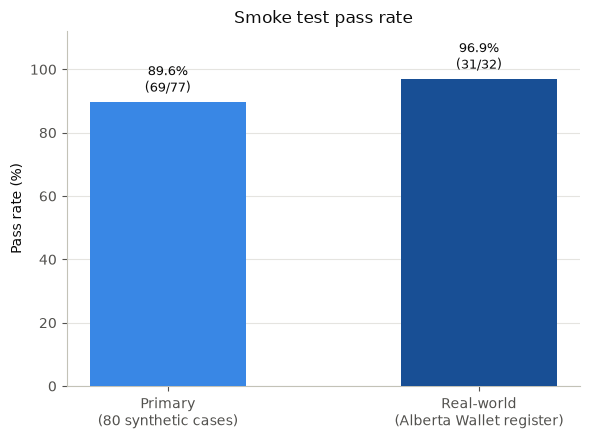

In [22]:
fig, ax = plt.subplots(figsize=(6, 4.5))
names = ["Primary\n(80 synthetic cases)", "Real-world\n(Alberta Wallet register)"]
rates = [100 * main_passed / main_scored, 100 * rw_passed / rw_scored]
counts = [f"{main_passed}/{main_scored}", f"{rw_passed}/{rw_scored}"]
bars = ax.bar(names, rates, color=[SEQ_BLUE[3], SEQ_BLUE[5]], width=0.5, zorder=3)
for bar, rate, cnt in zip(bars, rates, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, rate + 2, f"{rate:.1f}%\n({cnt})",
            ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, 112)
ax.set_ylabel("Pass rate (%)")
ax.set_title("Smoke test pass rate")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.grid(axis="y", color="#e5e4e0", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig("smoke_test_pass_rate.png", dpi=140)
plt.show()


## 5. Summary dashboard

One figure combining the headline numbers from every section above: per-type
F1, the confusion matrix, the ROC curve, and smoke test pass rates.

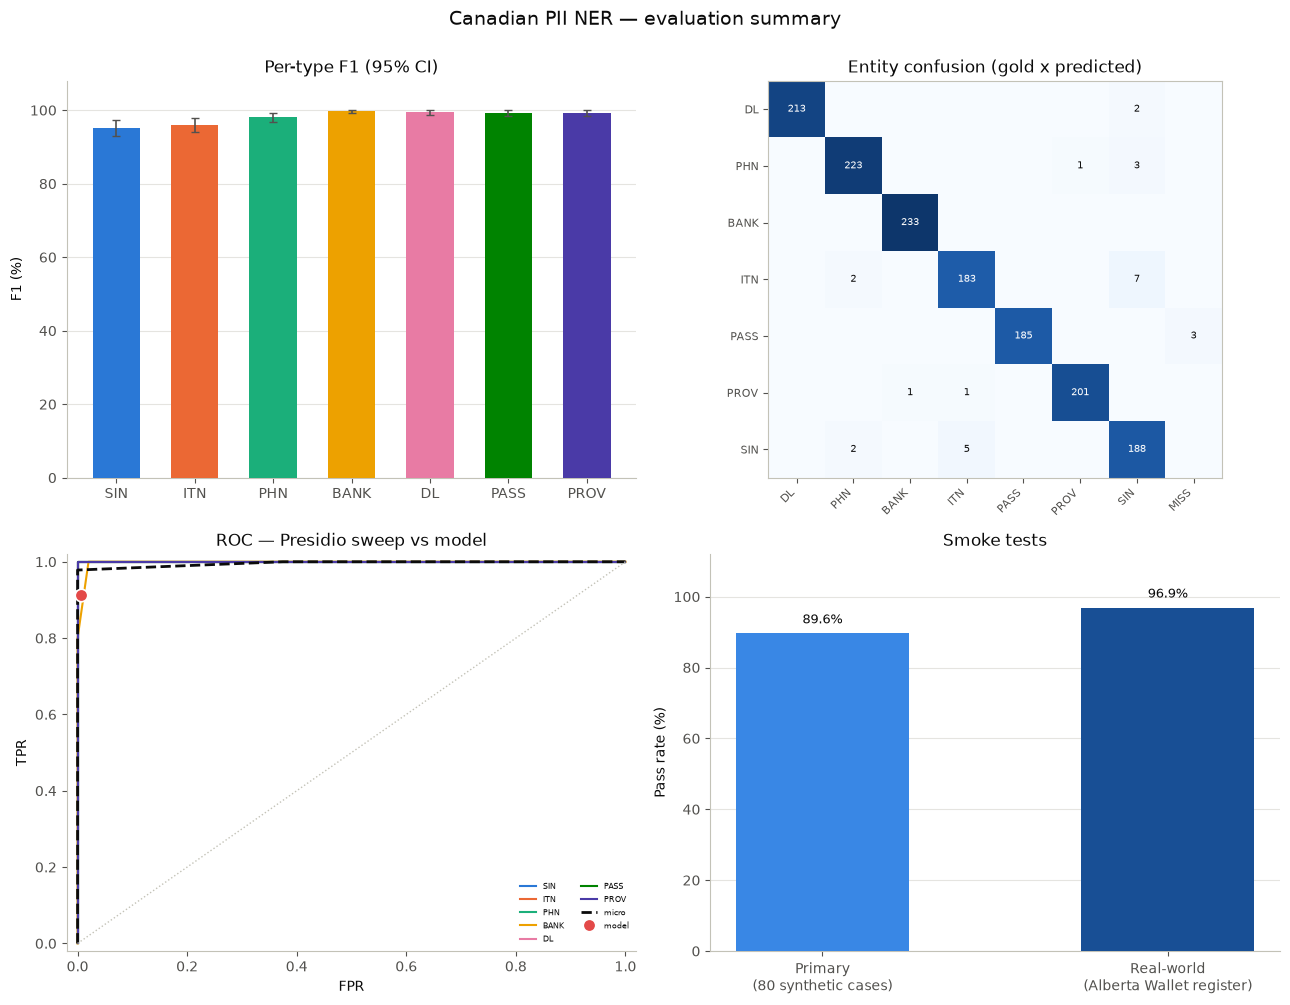

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# per-type F1
ax = axes[0, 0]
bars = ax.bar(xlabels, f1, color=colors, width=0.6, zorder=3)
ax.errorbar(xlabels, f1, yerr=err, fmt="none", ecolor="#52514e", elinewidth=1.2, capsize=3, zorder=4)
ax.set_ylim(0, 108); ax.set_ylabel("F1 (%)"); ax.set_title("Per-type F1 (95% CI)")
for side in ("top", "right"): ax.spines[side].set_visible(False)
ax.grid(axis="y", color="#e5e4e0", linewidth=0.8, zorder=0); ax.set_axisbelow(True)

# confusion matrix
ax = axes[0, 1]
im = ax.imshow(M, cmap=BLUE_CMAP)
ax.set_xticks(range(K + 1)); ax.set_xticklabels(axis, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(K)); ax.set_yticklabels([SHORT.get(l, l) for l in labels], fontsize=8)
ax.set_title("Entity confusion (gold x predicted)")
for i in range(K):
    for j in range(K + 1):
        if M[i, j]:
            ax.text(j, i, M[i, j], ha="center", va="center", fontsize=7,
                    color="white" if M[i, j] > M.max() / 2 else "#0b0b0b")

# ROC
ax = axes[1, 0]
for t in TYPE_ORDER:
    if t in roc:
        fpr, tpr, a = roc[t]
        ax.plot(fpr, tpr, color=TYPE_COLOR[t], linewidth=1.5, label=SHORT[t])
ax.plot(fpr_micro, tpr_micro, color="#0b0b0b", linewidth=2, linestyle="--", label="micro")
ax.plot([model_fpr], [model_tpr], marker="o", markersize=9, color="#e34948",
        markeredgecolor="white", markeredgewidth=1.2, linestyle="none", zorder=5, label="model")
ax.plot([0, 1], [0, 1], color="#c3c2b7", linewidth=1, linestyle=":")
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("ROC \u2014 Presidio sweep vs model")
ax.legend(frameon=False, fontsize=6, loc="lower right", ncol=2)
for side in ("top", "right"): ax.spines[side].set_visible(False)

# smoke test pass rates
ax = axes[1, 1]
bars = ax.bar(names, rates, color=[SEQ_BLUE[3], SEQ_BLUE[5]], width=0.5, zorder=3)
for bar, rate, cnt in zip(bars, rates, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, rate + 2, f"{rate:.1f}%",
            ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, 112); ax.set_ylabel("Pass rate (%)"); ax.set_title("Smoke tests")
for side in ("top", "right"): ax.spines[side].set_visible(False)
ax.grid(axis="y", color="#e5e4e0", linewidth=0.8, zorder=0); ax.set_axisbelow(True)

fig.suptitle("Canadian PII NER \u2014 evaluation summary", fontsize=14, y=1.0)
fig.tight_layout()
fig.savefig("evaluation_dashboard.png", dpi=140)
plt.show()


## 6. Save & download artifacts

Bundles every figure and metrics file produced above. Downloads the zip if
running in Colab; otherwise it's just left in the working directory.

In [24]:
import shutil, glob

ARTIFACTS = [
    "analysis_summary.json", "confusion_matrix.png", "per_type_f1.png",
    "ontonotes_per_type.png", "roc_curve.png", "pr_curve.png",
    "smoke_test_pass_rate.png", "evaluation_dashboard.png",
]
present = [a for a in ARTIFACTS if os.path.isfile(a)]
missing = [a for a in ARTIFACTS if a not in present]
print("Artifacts found:", present)
if missing:
    print("Missing (re-run the corresponding cell above):", missing)

os.makedirs("eval_artifacts", exist_ok=True)
for a in present:
    shutil.copy(a, os.path.join("eval_artifacts", a))
shutil.make_archive("evaluation_artifacts", "zip", "eval_artifacts")
print("Wrote evaluation_artifacts.zip")

try:
    from google.colab import files
    files.download("evaluation_artifacts.zip")
except ImportError:
    print("Not running in Colab \u2014 evaluation_artifacts.zip left in the working directory.")


Artifacts found: ['analysis_summary.json', 'confusion_matrix.png', 'per_type_f1.png', 'roc_curve.png', 'pr_curve.png', 'smoke_test_pass_rate.png', 'evaluation_dashboard.png']
Missing (re-run the corresponding cell above): ['ontonotes_per_type.png']
Wrote evaluation_artifacts.zip
Not running in Colab — evaluation_artifacts.zip left in the working directory.
